In [1]:
import matplotlib.pyplot as plt

import gudhi as gd 
import numpy as np 
import tensorflow as tf 

from utils import *

Reference diagram: [[1. 2.]
 [0. 2.]]
Reference diagram Matteo paper: [[1. 2.]
 [0. 3.]]
Reference persistent entropy: 0.6365142
Reference persistent entropy (Matteo paper): 0.56233513
PET shape: (64,)
First values: tf.Tensor([-0. -0. -0. -0. -0.], shape=(5,), dtype=float32)


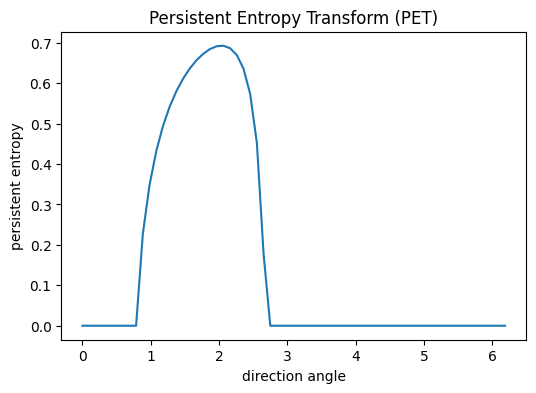

In [8]:
n_points = 3
x_train = tf.constant([1.,2.,3.],dtype=tf.float32)
y_train = tf.constant([0.,2.,1.],dtype=tf.float32)

stbase = gd.SimplexTree()
for i in range(n_points-1):
    stbase.insert([i,i+1], -1e10)
layer = LowerStarLayer(simplextree=stbase)

dgmsRef = layer.call(y_train)
dgmRef = dgmsRef[0][0]

print("Reference diagram:", dgmRef.numpy())

# cambiar un valor de dgmRef, quiero modificar la segunda coordenada de la segunda fila, 
# esto si quieres calcular la misma PE que en el artículo de Matteo.
dgmRefMat = tf.tensor_scatter_nd_update(dgmRef, [[1,1]], [3.])

print("Reference diagram Matteo paper:", dgmRefMat.numpy())

PERef=persistent_entropy(dgmRef)

print("Reference persistent entropy:", PERef.numpy())

print("Reference persistent entropy (Matteo paper):", persistent_entropy(dgmRefMat).numpy())


PET_values, angles = persistent_entropy_transform(
    x_train,
    y_train,
    layer,
    num_directions=64
)

print("PET shape:", PET_values.shape)
print("First values:", PET_values[:5])


plt.figure(figsize=(6,4))
plt.plot(angles, PET_values.numpy())
plt.xlabel("direction angle")
plt.ylabel("persistent entropy")
plt.title("Persistent Entropy Transform (PET)")
plt.show()

Persistent Entropy Signal 1: 3.1851635
Persistent Entropy Signal 2: 3.2339256
Persistent Entropy Signal 3: 3.2150743


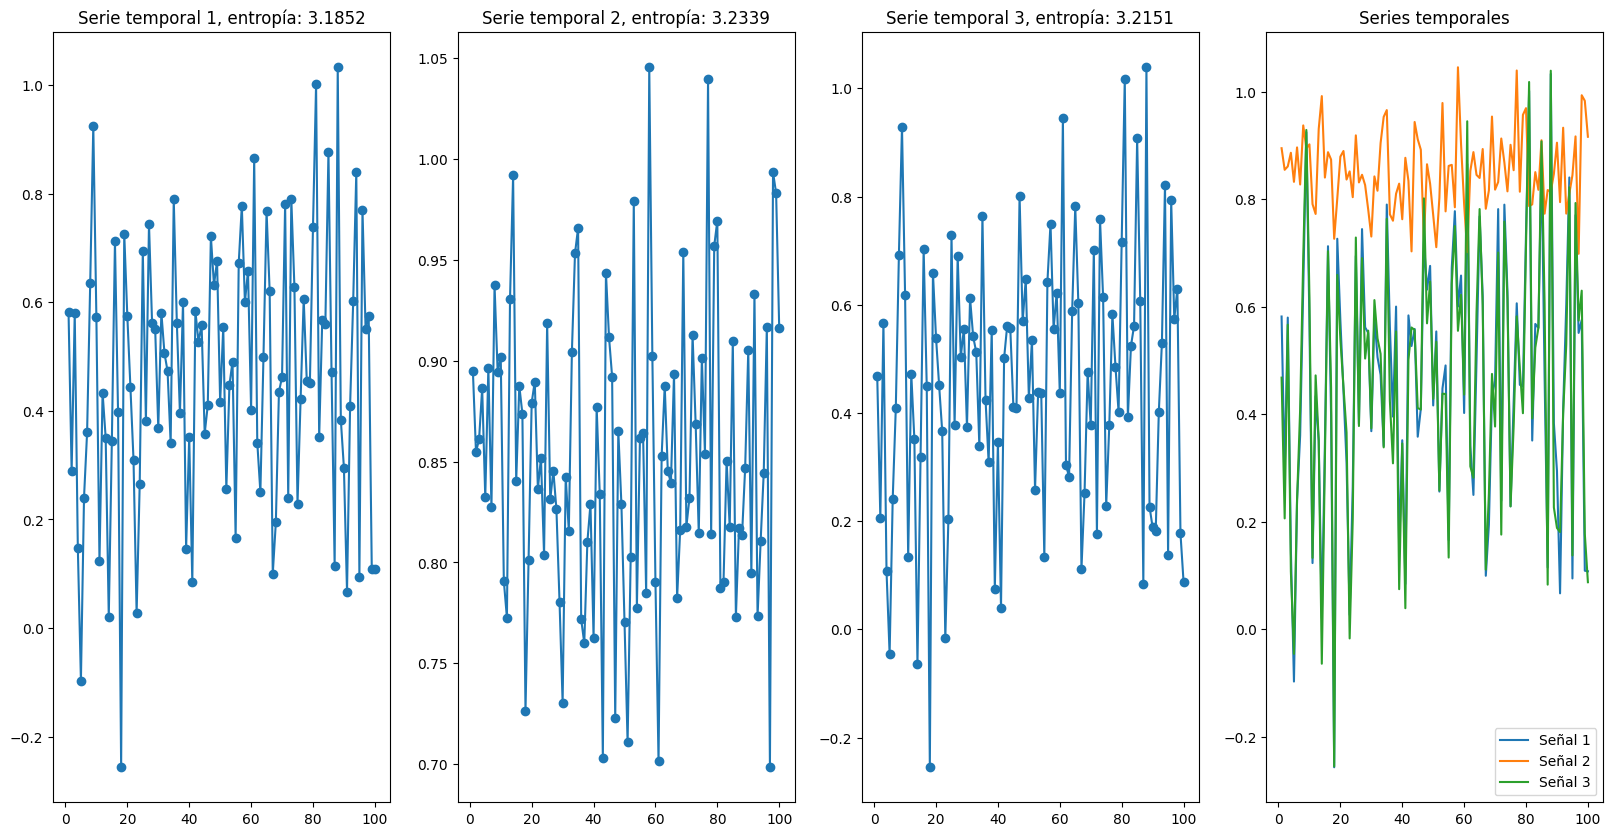

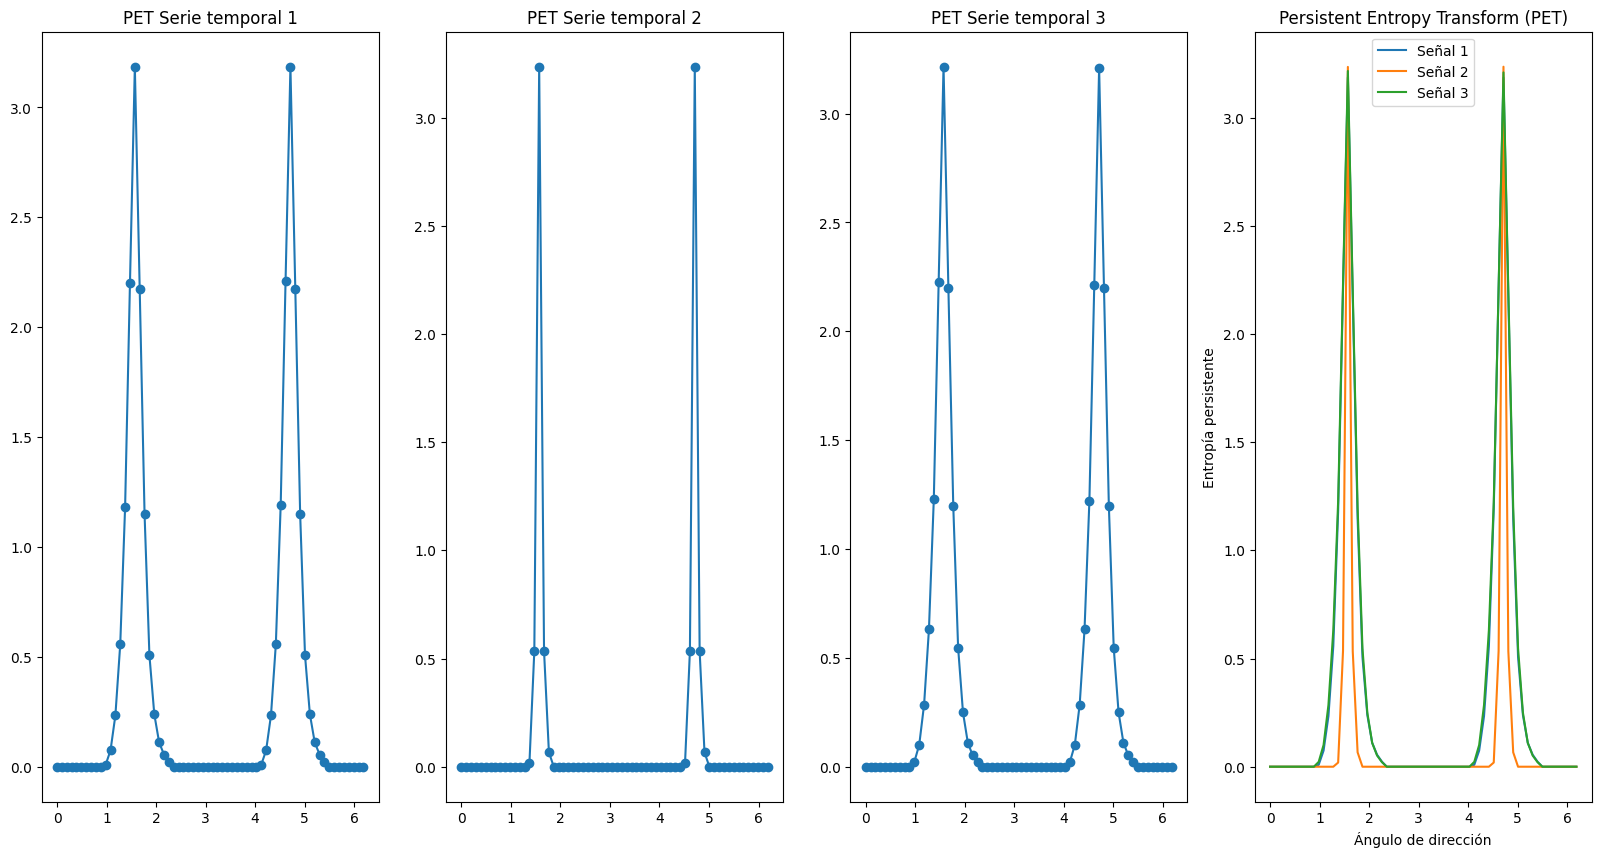

In [18]:
import matplotlib.gridspec as gridspec

def compute_topological_quantities(x, y, layer, num_directions=64):
    
    # Compute persistence diagram
    dgms = layer.call(y)
    dgm = dgms[0][0]
    
    # Persistent entropy
    pe = persistent_entropy(dgm)
    
    # Persistent entropy transform
    PET_values, angles = persistent_entropy_transform(
        x,
        y,
        layer,
        num_directions=num_directions
    )
    
    return dgm, pe, PET_values, angles

tf.random.set_seed(42)

N = 100
t = tf.range(1, N+1, dtype=tf.float32)

# Signal 1
signal_1 = tf.random.normal(
    shape=(N,),
    mean=0.5,
    stddev=0.25,
    dtype=tf.float32
)

# Change seed
tf.random.set_seed(7)

# Signal 2
signal_2 = tf.random.normal(
    shape=(N,),
    mean=0.85,
    stddev=0.075,
    dtype=tf.float32
)

# Noise
noise = tf.random.normal(
    shape=(N,),
    mean=0.0,
    stddev=0.05,
    dtype=tf.float32
)

# Signal 3
signal_3 = signal_1 + noise

stbase = gd.SimplexTree()
for i in range(N-1):
    stbase.insert([i,i+1], -1e10)
layer = LowerStarLayer(simplextree=stbase)

dgm1, pe1, PET1, angles = compute_topological_quantities(t, signal_1, layer)
dgm2, pe2, PET2, _ = compute_topological_quantities(t, signal_2, layer)
dgm3, pe3, PET3, _ = compute_topological_quantities(t, signal_3, layer)

print("Persistent Entropy Signal 1:", pe1.numpy())
print("Persistent Entropy Signal 2:", pe2.numpy())
print("Persistent Entropy Signal 3:", pe3.numpy())

fig = plt.figure(figsize=(20, 10)) 
gs = gridspec.GridSpec(1, 4, wspace=0.2, hspace=0.2)

signals = [signal_1, signal_2, signal_3]
entropies = [pe1.numpy(), pe2.numpy(), pe3.numpy()]

for i in range(3):
    ax = plt.subplot(gs[0,i])
    ax.plot(t.numpy(), signals[i].numpy(), '-o')
    ax.set_title(f"Serie temporal {i+1}, entropía: {entropies[i]:.4f}")

ax3 = plt.subplot(gs[0,3])
ax3.plot(t.numpy(), signal_1.numpy(), label='Señal 1')
ax3.plot(t.numpy(), signal_2.numpy(), label='Señal 2')
ax3.plot(t.numpy(), signal_3.numpy(), label='Señal 3')
ax3.set_title("Series temporales")
ax3.legend()

plt.show()

# dibujamos las PET ahora, 1 grafico por PET y luego un grafico con las 3 PET juntas, para comparar.

fig = plt.figure(figsize=(20, 10)) 
gs = gridspec.GridSpec(1, 4, wspace=0.2, hspace=0.2)
PETs = [PET1, PET2, PET3]
for i in range(3):
    ax = plt.subplot(gs[0,i])
    ax.plot(angles, PETs[i], '-o')
    ax.set_title(f"PET Serie temporal {i+1}")

ax3 = plt.subplot(gs[0,3])
ax3.plot(angles, PET1.numpy(), label='Señal 1')
ax3.plot(angles, PET2.numpy(), label='Señal 2')
ax3.plot(angles, PET3.numpy(), label='Señal 3')
ax3.set_title("PETs de las series temporales")
plt.xlabel("Ángulo de dirección")
plt.ylabel("Entropía persistente")
plt.title("Persistent Entropy Transform (PET)")
plt.legend()
plt.show()

PE reference: 0.63230586
PE blue: 0.63218445
PE green: 0.6318144


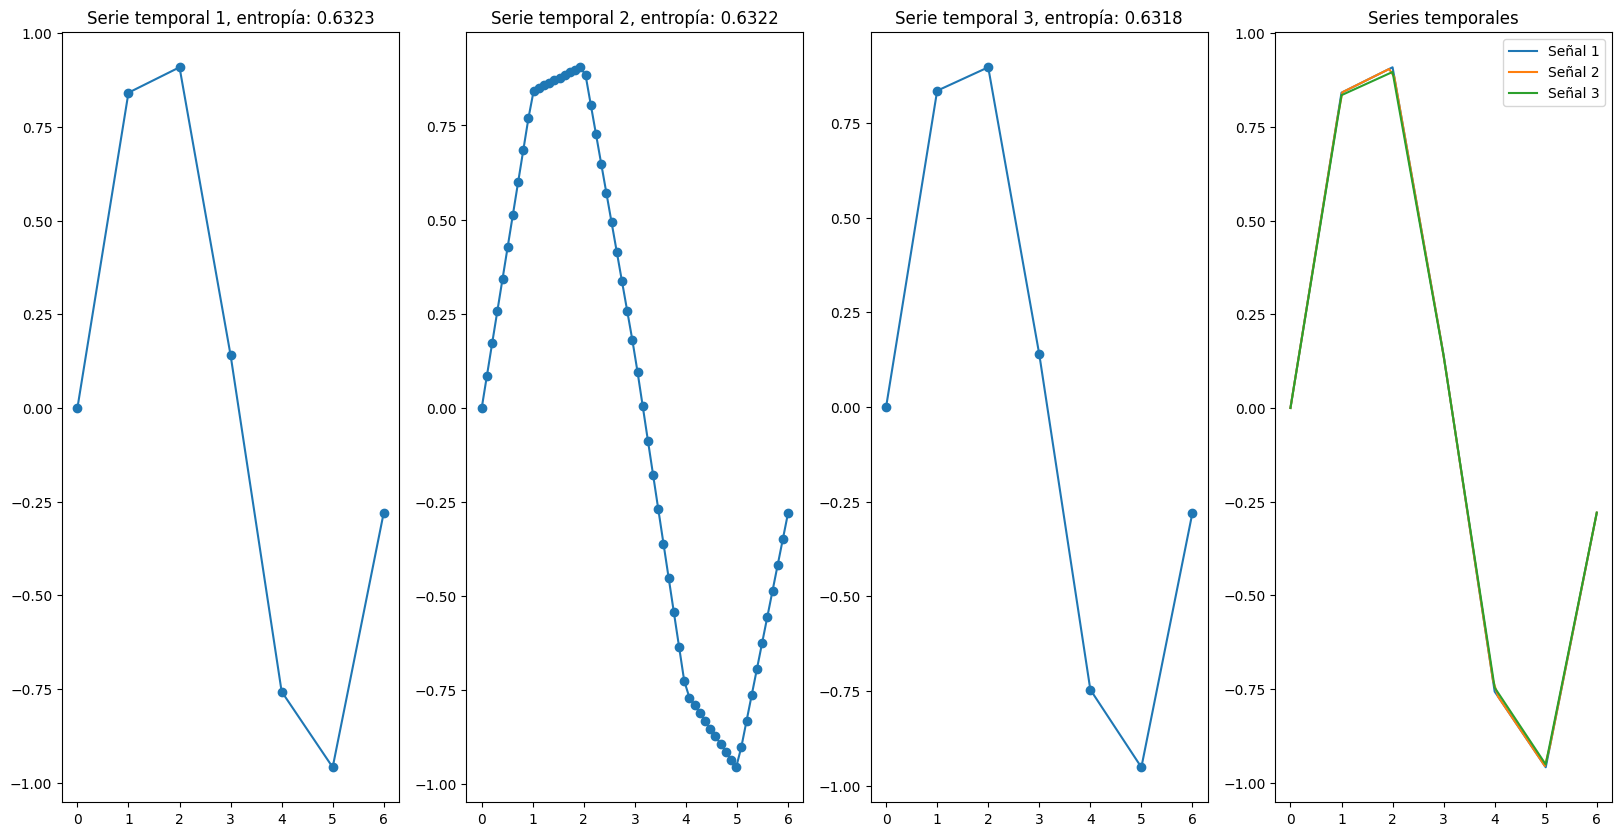

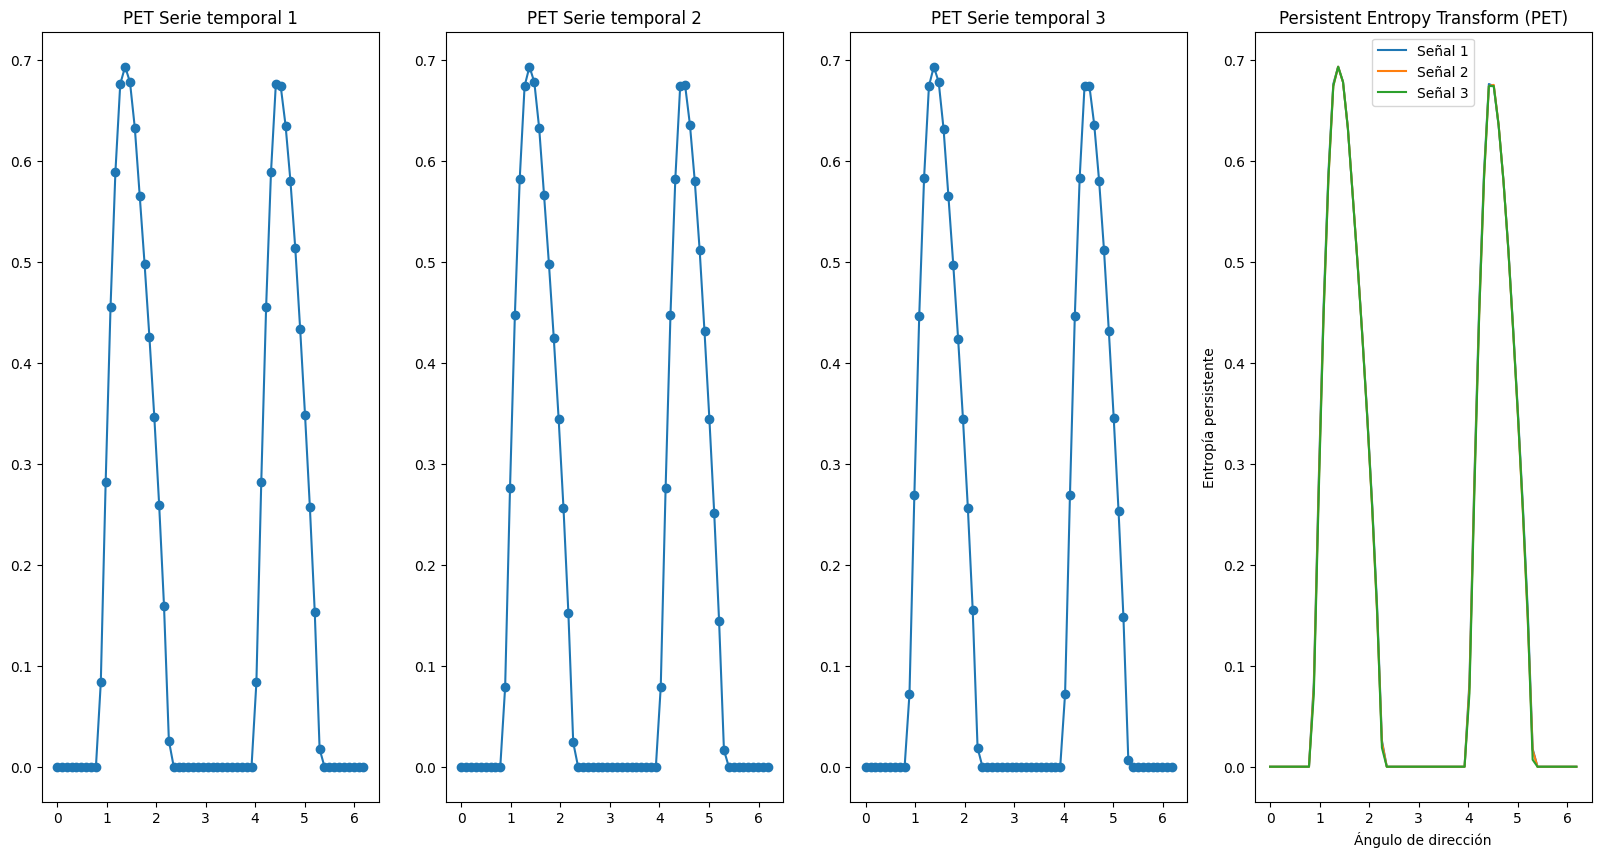

In [25]:
from scipy.interpolate import interp1d

def build_lower_star_layer(n_points):
    stbase = gd.SimplexTree()
    for i in range(n_points - 1):
        stbase.insert([i, i+1], -1e10)
    return LowerStarLayer(simplextree=stbase)

def compute_topology(x, y, num_directions=64):

    layer = build_lower_star_layer(len(y))
    
    # Persistence diagram
    dgms = layer.call(y)
    dgm = dgms[0][0]
    
    # Persistent entropy
    pe = persistent_entropy(dgm)
    
    # Persistent Entropy Transform
    PET_values, angles = persistent_entropy_transform(
        x,
        y,
        layer,
        num_directions=num_directions
    )
    
    return dgm, pe, PET_values, angles

# Reference signal (red)
x_ref = np.array([0, 1, 2, 3, 4, 5, 6])
y_ref = np.sin(x_ref)

# Blue signal (linear interpolation)
x_blue = np.linspace(0, 6, 60)
interpolador_linear = interp1d(x_ref, y_ref, kind='linear', fill_value="extrapolate")
y_blue = interpolador_linear(x_blue)

# Green signal (cubic interpolation evaluated at original points)
interpolador_cubic = interp1d(x_blue, y_blue, kind='cubic')
y_green = interpolador_cubic(x_ref)

x_ref = tf.constant(x_ref, dtype=tf.float32)
y_ref = tf.constant(y_ref, dtype=tf.float32)

x_blue = tf.constant(x_blue, dtype=tf.float32)
y_blue = tf.constant(y_blue, dtype=tf.float32)

y_green = tf.constant(y_green, dtype=tf.float32)

dgm_ref, pe_ref, PET_ref, angles_ref = compute_topology(x_ref, y_ref)

dgm_blue, pe_blue, PET_blue, angles_blue = compute_topology(x_blue, y_blue)

dgm_green, pe_green, PET_green, angles_green = compute_topology(x_ref, y_green)

print("PE reference:", pe_ref.numpy())
print("PE blue:", pe_blue.numpy())
print("PE green:", pe_green.numpy())

fig = plt.figure(figsize=(20, 10)) 
gs = gridspec.GridSpec(1, 4, wspace=0.2, hspace=0.2)

signals = [y_ref, y_blue, y_green]
xs = [x_ref, x_blue, x_ref]
entropies = [pe_ref.numpy(), pe_blue.numpy(), pe_green.numpy()]

for i in range(3):
    ax = plt.subplot(gs[0,i])
    ax.plot(xs[i].numpy(), signals[i].numpy(), '-o')
    ax.set_title(f"Serie temporal {i+1}, entropía: {entropies[i]:.4f}")

ax3 = plt.subplot(gs[0,3])
ax3.plot(x_ref.numpy(), y_ref.numpy(), label='Señal 1')
ax3.plot(x_blue.numpy(), y_blue.numpy(), label='Señal 2')
ax3.plot(x_ref.numpy(), y_green.numpy(), label='Señal 3')
ax3.set_title("Series temporales")
ax3.legend()

plt.show()

# dibujamos las PET ahora, 1 grafico por PET y luego un grafico con las 3 PET juntas, para comparar.

fig = plt.figure(figsize=(20, 10)) 
gs = gridspec.GridSpec(1, 4, wspace=0.2, hspace=0.2)
PETs = [PET_ref, PET_blue, PET_green]
for i in range(3):
    ax = plt.subplot(gs[0,i])
    ax.plot(angles, PETs[i], '-o')
    ax.set_title(f"PET Serie temporal {i+1}")

ax3 = plt.subplot(gs[0,3])
ax3.plot(angles, PET_ref.numpy(), label='Señal 1')
ax3.plot(angles, PET_blue.numpy(), label='Señal 2')
ax3.plot(angles, PET_green.numpy(), label='Señal 3')
ax3.set_title("PETs de las series temporales")
plt.xlabel("Ángulo de dirección")
plt.ylabel("Entropía persistente")
plt.title("Persistent Entropy Transform (PET)")
plt.legend()
plt.show()

PE 1: 0.9950274
PE 2: 0.9950274
PE 3: 0.9950274


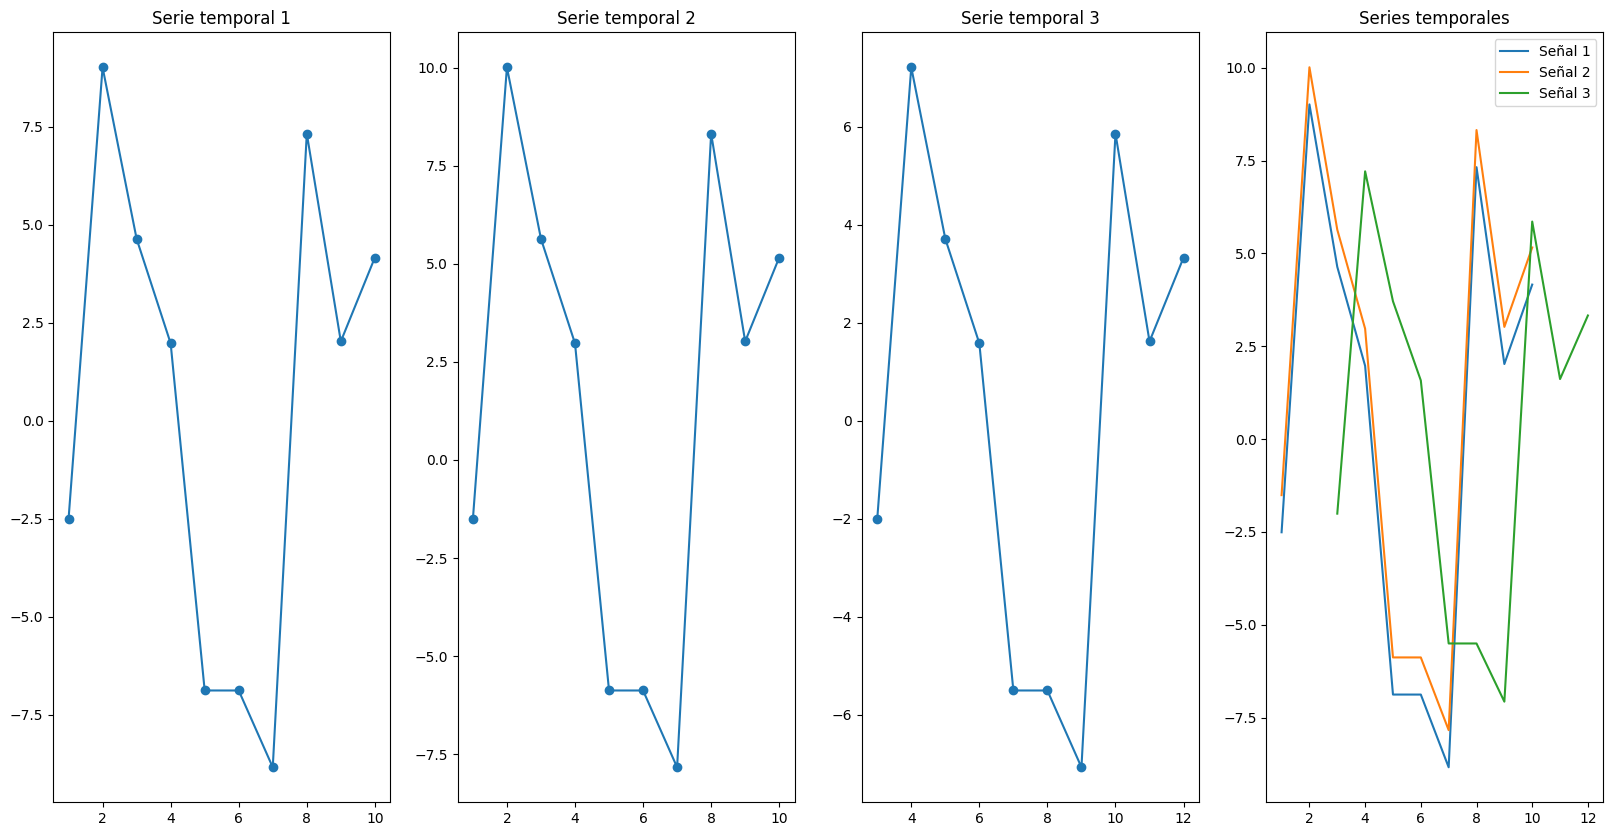

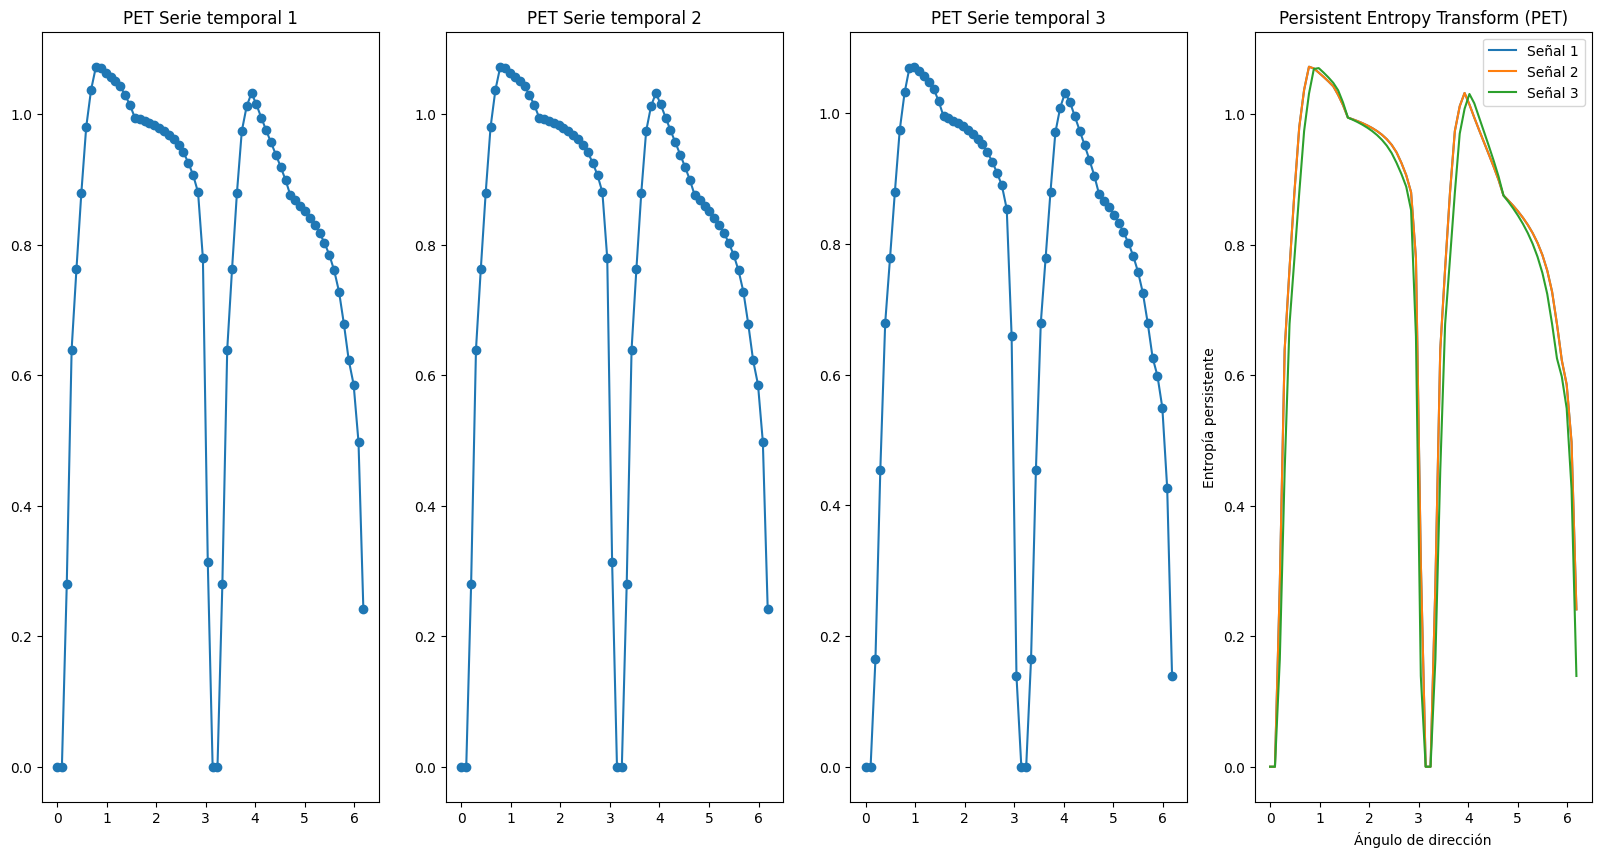

In [28]:
np.random.seed(42)
N = 10 #The number of points
tref = np.arange(1,N+1,1)

signal_1 = np.random.uniform(-10, 10, N)

signal_2 = signal_1 + 1

desplazamiento_x = 2 
t3=tref+desplazamiento_x
signal_3 = signal_1 * 0.8  #realmente esto es quitando amplitud, shifted(desplazamiento) es sumando o restando

# las pasamos a tf.constant
signal_1 = tf.constant(signal_1, dtype=tf.float32)
signal_2 = tf.constant(signal_2, dtype=tf.float32)
signal_3 = tf.constant(signal_3, dtype=tf.float32)
tref = tf.constant(tref, dtype=tf.float32)
t3 = tf.constant(t3, dtype=tf.float32)

dgm1, pe1, PET1, angles1 = compute_topology(tref, signal_1)

dgm2, pe2, PET2, angles2 = compute_topology(tref, signal_2)

dgm3, pe3, PET3, angles3 = compute_topology(t3, signal_3)

print("PE 1:", pe1.numpy())
print("PE 2:", pe2.numpy())
print("PE 3:", pe3.numpy())

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(1, 4, wspace=0.2, hspace=0.2)
signals = [signal_1, signal_2, signal_3]
ts = [tref, tref, t3]
for i in range(3):
    ax = plt.subplot(gs[0,i])
    ax.plot(ts[i].numpy(), signals[i].numpy(), '-o')
    ax.set_title(f"Serie temporal {i+1}")
ax3 = plt.subplot(gs[0,3])
ax3.plot(tref.numpy(), signal_1.numpy(), label='Señal 1')
ax3.plot(tref.numpy(), signal_2.numpy(), label='Señal 2')
ax3.plot(t3.numpy(), signal_3.numpy(), label='Señal 3')
ax3.set_title("Series temporales")
ax3.legend()
plt.show()

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(1, 4, wspace=0.2, hspace=0.2)
PETs = [PET1, PET2, PET3]
for i in range(3):
    ax = plt.subplot(gs[0,i])
    ax.plot(angles1, PETs[i].numpy(), '-o')
    ax.set_title(f"PET Serie temporal {i+1}")
ax3 = plt.subplot(gs[0,3])
ax3.plot(angles1, PET1.numpy(), label='Señal 1')
ax3.plot(angles2, PET2.numpy(), label='Señal 2')
ax3.plot(angles3, PET3.numpy(), label='Señal 3')
ax3.set_title("PETs de las series temporales")
plt.xlabel("Ángulo de dirección")
plt.ylabel("Entropía persistente")
plt.title("Persistent Entropy Transform (PET)")
plt.legend()
plt.show()

DC classification

In [32]:
# Inicializar listas para almacenar los datos y etiquetas
import os
from scipy.io import wavfile

data = []
times=[]
labels = []
sample_rates=[]
fallo=0
# Lista con los nombres de las carpetas de interés
carpetas = ["Bearing", "Healthy", "Propeller"]

# Recorrer cada carpeta
for carpeta in carpetas:
    # Crear la ruta completa de la carpeta
    carpeta_path = os.path.join("BLDC_sound_data", carpeta)
    # Verificar si el directorio existe
    if not os.path.exists(carpeta_path):
        continue

    # Recorrer cada subcarpeta dentro de la carpeta principal
    for subcarpeta in os.listdir(carpeta_path):
        subcarpeta_path = os.path.join(carpeta_path, subcarpeta)
        # Verificar si es un directorio
        if os.path.isdir(subcarpeta_path):
            # Recorrer cada archivo .wav dentro de la subcarpeta
            for archivo in os.listdir(subcarpeta_path):
                if archivo.endswith(".wav"):
                    # Ruta completa del archivo .wav
                    wav_path = os.path.join(subcarpeta_path, archivo)

                    # Leer el archivo .wav
                    sample_rate, audio_data = wavfile.read(wav_path)
                    
                    # Verificar el sample rate y continuar solo si es 16000
                    if sample_rate == 16000:
                        # Agregar los datos de audio al array
                        data.append(audio_data[:160001,0].astype(np.int32))
                        time = np.array([i / sample_rate for i in range(len(audio_data))])
                        times.append(time[:160001])
                        sample_rates.append(sample_rate)
                        # Asignar etiquetas según la carpeta
                        if carpeta == "Healthy":
                            labels.append(1)  # Etiqueta 1 para Healthy
                        else:
                            labels.append(0)  # Etiqueta 0 para Bearing o Propeller como Fallo
                    else:
                        fallo += 1


# Ahora data_array contiene los datos de audio, y labels_array contiene las etiquetas
print("Número total de archivos procesados:", len(data))
print("Datos de audio shape:", data[0].shape)
print("Datos de audio shape:", times[0].shape)
print("Etiquetas shape:", len(labels))
print("Numero de muestras con sample rate distinta de 16kHz: ", fallo)
np.unique(labels,return_counts=True)

Número total de archivos procesados: 42
Datos de audio shape: (160001,)
Datos de audio shape: (160001,)
Etiquetas shape: 42
Numero de muestras con sample rate distinta de 16kHz:  1


(array([0, 1]), array([21, 21]))

In [34]:
from tqdm import tqdm

PET_features = []
labels_tf = []

for j in tqdm(range(len(labels))):

    x_tf = tf.constant(times[j], dtype=tf.float32)
    y_tf = tf.constant(data[j], dtype=tf.float32)

    layer = build_lower_star_layer(len(y_tf))

    PET_values, angles = persistent_entropy_transform(
        x_tf,
        y_tf,
        layer,
        num_directions=64
    )

    PET_features.append(PET_values.numpy())
    labels_tf.append(labels[j])

PET_features = np.array(PET_features)
labels_tf = np.array(labels_tf)

100%|██████████| 42/42 [10:48<00:00, 15.43s/it]


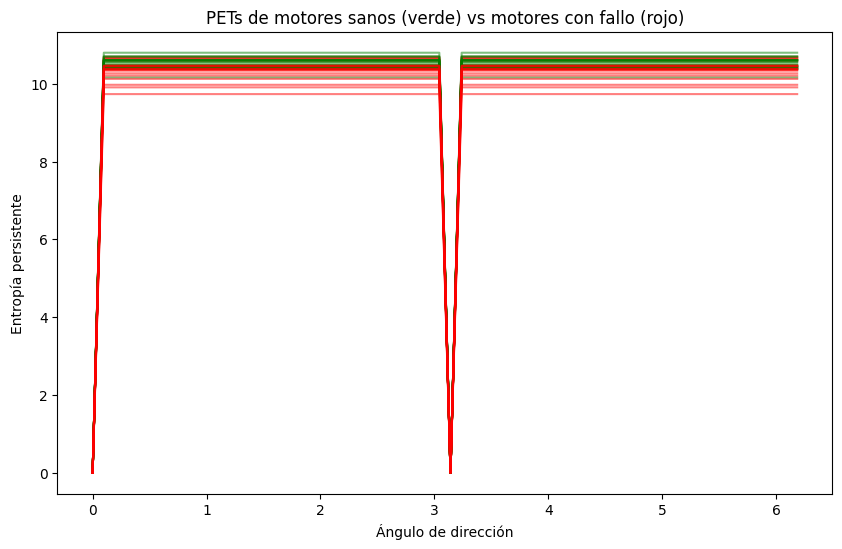

In [35]:
# visualizar todas las PET en un gráfico, en verde de motores sanos y en rojo de motores con fallo
plt.figure(figsize=(10, 6))
for i in range(len(PET_features)):
    if labels_tf[i] == 1:
        plt.plot(angles, PET_features[i], color='green', alpha=0.5)
    else:
        plt.plot(angles, PET_features[i], color='red', alpha=0.5)
plt.xlabel("Ángulo de dirección")
plt.ylabel("Entropía persistente")
plt.title("PETs de motores sanos (verde) vs motores con fallo (rojo)")
plt.show()

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    PET_features,
    labels_tf,
    test_size=0.3,
    stratify=labels_tf,
    random_state=42
)

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)

y_prob = clf.predict_proba(X_test)[:,1]

auc_pet = roc_auc_score(y_test, y_prob)
print("AUC using PET:", auc_pet)

AUC using PET: 0.7619047619047619


y con la PE basica?

100%|██████████| 42/42 [00:14<00:00,  2.89it/s]


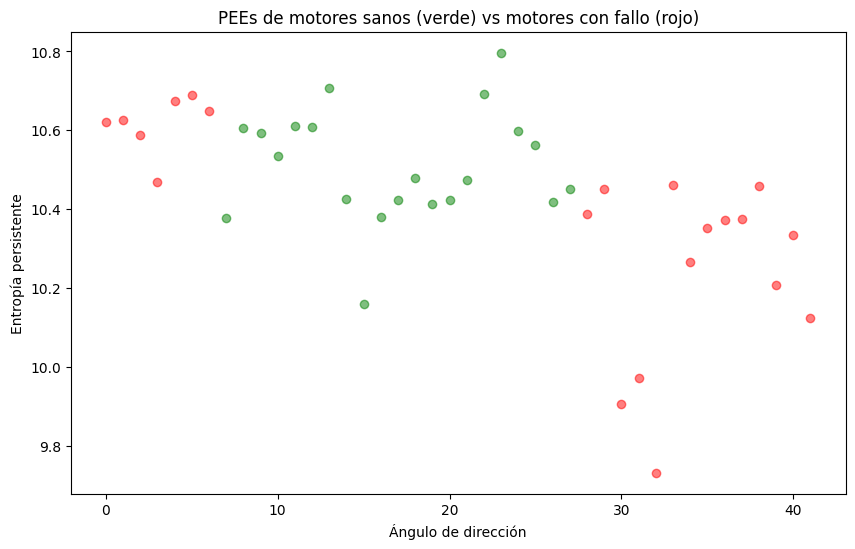

AUC using PET: 0.7619047619047619


In [ ]:
from tqdm import tqdm

PE_features = []
labels_tf = []

def compute_pe(x, y, layer):
    
    # Compute persistence diagram
    dgms = layer.call(y)
    dgm = dgms[0][0]
    
    # Persistent entropy
    pe = persistent_entropy(dgm)
    
    return pe

for j in tqdm(range(len(labels))):

    x_tf = tf.constant(times[j], dtype=tf.float32)
    y_tf = tf.constant(data[j], dtype=tf.float32)

    layer = build_lower_star_layer(len(y_tf))

    PE_value = compute_pe(x_tf, y_tf, layer)

    PE_features.append(PE_value.numpy())
    labels_tf.append(labels[j])

PE_features = np.array(PE_features)
labels_tf = np.array(labels_tf)

# visualizar todas las PET en un gráfico, en verde de motores sanos y en rojo de motores con fallo
plt.figure(figsize=(10, 6))
for i in range(len(PE_features)):
    if labels_tf[i] == 1:
        plt.scatter(i, PE_features[i], color='green', alpha=0.5)
    else:
        plt.scatter(i, PE_features[i], color='red', alpha=0.5)
plt.xlabel("Ángulo de dirección")
plt.ylabel("Entropía persistente")
plt.title("PEEs de motores sanos (verde) vs motores con fallo (rojo)")
plt.show()

# es una unica feature por lo que hacer reshape
PE_features = PE_features.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(
    PE_features,
    labels_tf,
    test_size=0.3,
    stratify=labels_tf,
    random_state=42
)

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)

y_prob = clf.predict_proba(X_test)[:,1]

auc_pet = roc_auc_score(y_test, y_prob)
print("AUC using PE:", auc_pet)